# Description

After EDA, we need to preprocess our data, train some models, and evaluate them. This notebook includes creating a data preprocessing pipeline that processes categorical and numerical features and handles class imbalance. Then we will train classic models for binary classification, such as logistic regression and support vector machines. We will also train powerful models like random forest and XGBoost, which work well with non-linear data. For each model, we will use grid search to find the best hyperparameters. <br>

To evaluate the models, we will use a confusion matrix and a classification report that includes important metrics. After identifying the best model, we will test it using cross-validation. We will also check feature importance using random forest.  <br>

Structure of this notebook:

1. Import libraries
2. Load data
3. Train-test split
4. Data preprocessing pipeline
5. Model training and evaluation
6. Cross-validation
7. Feature importance
8. Save models

# Import libraries

In [1]:
# Libraries for data preprocessing

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [2]:
# Libraries for model training and evaluation

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate

In [3]:
# Library for saving models

import joblib

In [4]:
# This is done to avoid seeing warnings in Jupyter Notebook

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Random seed for reproducibility 

SEED = 44

# Load data

In [6]:
# Load data 

df = pd.read_csv('../data/dataset.csv')

In [7]:
# Transform the credit_history column to a category to process it as a nominal categorical column

def transform_to_cat( item ):

    if item == 1.0:
        return 'yes'
    elif item == 0.0:
        return 'no'
    
    return item


df['credit_history'] = df['credit_history'].apply( transform_to_cat )

We could leave this column in its original numerical format, but it is actually a categorical column with two possible values. We changed it so that we can use a categorical imputer instead of a numerical one, such as the mean strategy. 

In [8]:
# Transform the target column to numerical values

def transform_target( item ):

    if item == 'y':
        return 1.0
    
    return 0.0


df['loan_status'] = df['loan_status'].apply( transform_target )

In [9]:
# Check first rows of the data

df.head(10)

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,lp001002,male,no,0,graduate,no,5849,0.0,NaN,360.0,yes,urban,1.0
1,lp001003,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,yes,rural,0.0
2,lp001005,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,yes,urban,1.0
3,lp001006,male,yes,0,not graduate,no,2583,2358.0,120.0,360.0,yes,urban,1.0
4,lp001008,male,no,0,graduate,no,6000,0.0,141.0,360.0,yes,urban,1.0
5,lp001011,male,yes,2,graduate,yes,5417,4196.0,267.0,360.0,yes,urban,1.0
6,lp001013,male,yes,0,not graduate,no,2333,1516.0,95.0,360.0,yes,urban,1.0
7,lp001014,male,yes,3+,graduate,no,3036,2504.0,158.0,360.0,no,semiurban,0.0
8,lp001018,male,yes,2,graduate,no,4006,1526.0,168.0,360.0,yes,urban,1.0
9,lp001020,male,yes,1,graduate,no,12841,10968.0,349.0,360.0,yes,semiurban,0.0


# Train test split

First of all, we need to split our data to avoid data leakage.

In [10]:
# Split the data into X (all features without the target and loan_id) and y (the target attribute).

X = df[['gender', 'married', 'dependents', 'education',	'self_employed', 'applicantincome', 
        'coapplicantincome', 'loanamount', 'loan_amount_term', 'credit_history', 'property_area']]

y = df['loan_status']

In [11]:
# Split the data into train and test parts (test_size = 30%)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

# Data preprocessing pipeline

In [12]:
# Split features based on their type

numerical_features = ['applicantincome', 'coapplicantincome', 'loanamount', 'loan_amount_term']
categorical_nominal_features = ['gender', 'married', 'education', 'self_employed', 'credit_history', 'property_area']
categorical_ordinal_features = ['dependents']

In [13]:
# Function that has one parameter, a model, and returns one value: a preprocessing pipeline that includes this model

def get_model_pipeline(model):

    num_preprocessing = Pipeline( steps=[
        ('num_imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ] )


    cat_nom_preprocessing = Pipeline( steps=[
        ('cat_nom_imuter', SimpleImputer(strategy='most_frequent')),
        ('one_hot_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ] )


    dependents = ['0', '1', '2', '3+']
    cat_ord_preprocessing = Pipeline( steps=[
        ('cat_ord_imputer', SimpleImputer(strategy='most_frequent')),
        ('ordinal_encoder', OrdinalEncoder(categories=[dependents]))
    ] )


    column_transformer = ColumnTransformer( transformers=[
        ('num', num_preprocessing, numerical_features),
        ('cat_nom', cat_nom_preprocessing, categorical_nominal_features),
        ('cat_ord', cat_ord_preprocessing, categorical_ordinal_features)
    ], remainder='drop' )


    final_pipeline = ImbPipeline( steps=[
        ('preprocessing', column_transformer),
        ('smote', SMOTE(random_state=SEED)),
        ('model', model)
    ] )

    return final_pipeline



This function returns a pipeline that includes preprocessing for each type of column. For numerical columns, we use an imputer with the "mean" strategy and a StandardScaler, which transforms the data to have zero mean and a standard deviation of 1. For categorical nominal features, we use an imputer with the "most_frequent" strategy and OneHotEncoder, which is used for columns without hierarchy in their values. For the categorical ordinal feature dependents, we also use an imputer with the "most_frequent" strategy and OrdinalEncoder. To handle class imbalance, we include an oversampling method called SMOTE, which creates new synthetic data points for the underrepresented class.

# Model training and evaluation

In [14]:
# Function to evaluate models

def evaluate(model, X_test, y_test):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

    cr = classification_report(y_test, y_pred)
    print(cr)

For model evaluation, we will use a confusion matrix and a classification report that includes important metrics such as accuracy, recall, precision, and F1 score.

## 1. Logistic regression

In [19]:
lr = LogisticRegression(random_state=SEED)
lr_pipeline = get_model_pipeline(lr)

param_grid_lr = [{
    'model__penalty': [None, 'l1', 'l2'],
    'model__C': [0.1, 1, 100, 1000],
    'model__max_iter': [20, 50, 100, 200, 500],
    'model__solver': ['lbfgs', 'liblinear', 'newton-cg']
}]

lr_gs = GridSearchCV(lr_pipeline, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
lr_gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=44))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.1, 1, ...], 'model__max_iter': [20, 50, ...], 'model__penalty': [None, 'l1', ...], 'model__solver': ['lbfgs', 'liblinear', ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

In [20]:
lr_gs.best_params_

{'model__C': 0.1,
 'model__max_iter': 20,
 'model__penalty': 'l1',
 'model__solver': 'liblinear'}

In [21]:
lr_best = lr_gs.best_estimator_

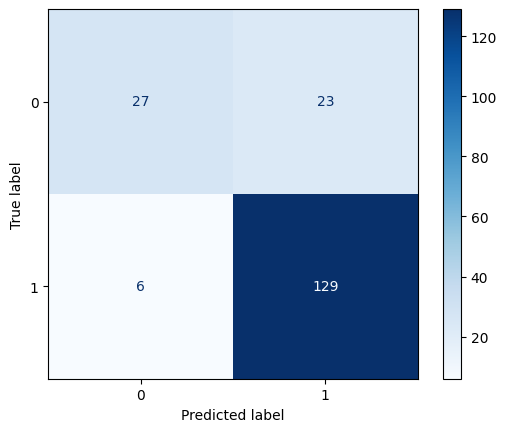

              precision    recall  f1-score   support

         0.0       0.82      0.54      0.65        50
         1.0       0.85      0.96      0.90       135

    accuracy                           0.84       185
   macro avg       0.83      0.75      0.77       185
weighted avg       0.84      0.84      0.83       185



In [22]:
evaluate(lr_best, X_test, y_test)

We see that the model has no problem with class 1 and shows good values for all metrics. For class 0, the model has quite good precision (0.82) but lower recall (0.54) and F1-score (0.65). This means that if the model predicts class 0, it is most likely correct. However, the model often predicts samples that are actually class 0 as class 1.

## 2. SVM

In [19]:
svm = SVC(random_state=SEED)
svc_pipeline = get_model_pipeline(svm)

param_grid_svm = [
    {'model__kernel': ['linear'], 'model__C': [0.1, 1, 10, 100]},
    {'model__kernel': ['rbf'], 'model__C': [0.1, 1, 10, 100], 'model__gamma': ['scale', 'auto']},
    {'model__kernel': ['poly', 'sigmoid'], 'model__C': [0.1, 1, 10, 100], 'model__gamma': ['scale', 'auto'], 
                                                                                    'model__coef0': [0, 1, 5]},
]

svm_gs = GridSearchCV(svc_pipeline, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
svm_gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=44))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.1, 1, ...], 'model__kernel': ['linear']}, {'model__C': [0.1, 1, ...], 'model__gamma': ['scale', 'auto'], 'model__kernel': ['rbf']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [20]:
svm_gs.best_params_

{'model__C': 0.1,
 'model__coef0': 0,
 'model__gamma': 'scale',
 'model__kernel': 'sigmoid'}

In [21]:
svm_best = svm_gs.best_estimator_

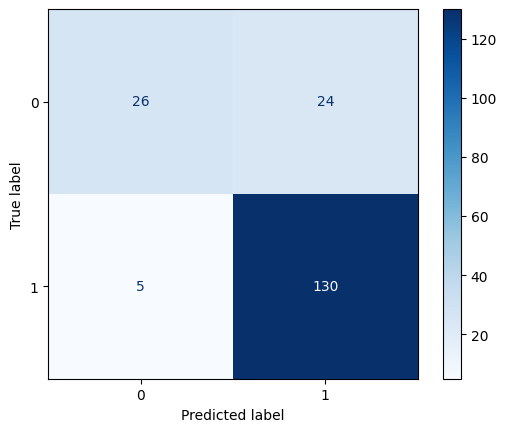

              precision    recall  f1-score   support

         0.0       0.84      0.52      0.64        50
         1.0       0.84      0.96      0.90       135

    accuracy                           0.84       185
   macro avg       0.84      0.74      0.77       185
weighted avg       0.84      0.84      0.83       185



In [22]:
evaluate(svm_best, X_test, y_test)

We can again see good results for class 1 and problems with class 0. The model has good precision for class 0, but recall and F1-score are a little worse than in logistic regression.

## 3. Random forest

In [15]:
rf = RandomForestClassifier(random_state=SEED)
rf_pipeline = get_model_pipeline(rf)

param_grid_rf = [{
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [3, 5, 10, 15, None],
    'model__min_samples_leaf': [1, 2, 3, 4, 5, 7, 10],
    'model__max_features': ['sqrt', 'log2'],
}]

rf_gs = GridSearchCV(rf_pipeline, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
rf_gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=44))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__max_depth': [3, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__n_estimators': [100, 200, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the compu

In [16]:
rf_gs.best_params_

{'model__max_depth': 3,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 1,
 'model__n_estimators': 200}

In [17]:
rf_best = rf_gs.best_estimator_

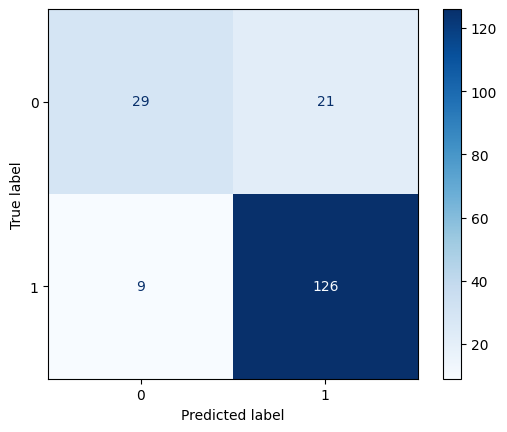

              precision    recall  f1-score   support

         0.0       0.76      0.58      0.66        50
         1.0       0.86      0.93      0.89       135

    accuracy                           0.84       185
   macro avg       0.81      0.76      0.78       185
weighted avg       0.83      0.84      0.83       185



In [18]:
evaluate(rf_best, X_test, y_test)

We can see that recall and F1-score for class 1 are a little worse than in logistic regression and SVM, but they are still good. For class 0, we see the best values of recall and F1-score so far.

## 4. XGBoost

In [27]:
xgboost = XGBClassifier(random_state=SEED)
xgboost_pipeline = get_model_pipeline(xgboost)

param_grid_xgboost = [{
    'model__learning_rate': [0.001, 0.01, 0.1],
    'model__n_estimators': [50, 100, 200],
    'model__subsample': [1.0, 0.8],
    'model__max_depth': [2, 3, 4]
}]

xgboost_gs = GridSearchCV(xgboost_pipeline, param_grid_xgboost, cv=5, scoring='accuracy', n_jobs=-1)
xgboost_gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__learning_rate': [0.001, 0.01, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [50, 100, ...], 'model__subsample': [1.0, 0.8]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

In [28]:
xgboost_gs.best_params_

{'model__learning_rate': 0.01,
 'model__max_depth': 2,
 'model__n_estimators': 50,
 'model__subsample': 0.8}

In [29]:
xgboost_best = xgboost_gs.best_estimator_

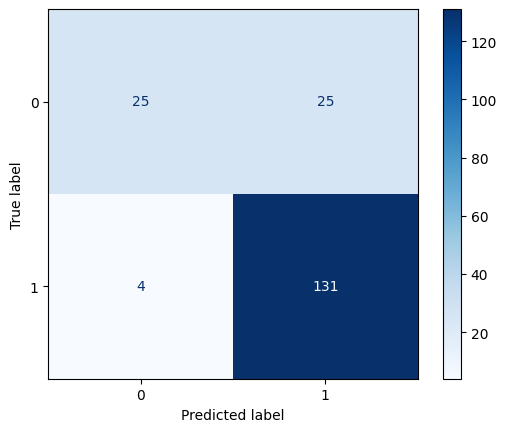

              precision    recall  f1-score   support

         0.0       0.86      0.50      0.63        50
         1.0       0.84      0.97      0.90       135

    accuracy                           0.84       185
   macro avg       0.85      0.74      0.77       185
weighted avg       0.85      0.84      0.83       185



In [30]:
evaluate(xgboost_best, X_test, y_test)

We can again see good results for class 1. For class 0, the model has the worst recall and F1-score compared to the other models, but it has the best precision. Maybe XGBoost does not work well in our case because we have a medium-size datase

# Cross-validation

Based on the model evaluation, we can say that every model achieves good results for class 1, but all models have problems with class 0. The best F1-score and recall for class 0 are achieved by the random forest model. If we also look at the confusion matrix, we can say that this model performs the best. To verify that the model works well with different data distributions and to get a more reliable evaluation of its performance, we need to use cross-validation.

In [47]:
best_params = dict( list( map(lambda x: (x[0].replace('model__', ''), x[1]), rf_gs.best_params_.items()) ) )
rf_cv = RandomForestClassifier(random_state=SEED, **best_params)
rf_cv_pipeline = get_model_pipeline(rf_cv)

scores = cross_validate(rf_cv_pipeline, X, y, cv=5, scoring=['precision_macro', 'recall_macro', 'f1_macro', 'accuracy'])

In [55]:
for item in list(scores.items())[2:]:

    print(f"Metric: {item[0].replace('test_', '')}\n")
    print(f'Values: {item[1]}')
    print(f'Mean: {item[1].mean()}')
    print(f'Standart deviation: {item[1].std()}\n\n')

Metric: precision_macro

Values: [0.83968254 0.78942757 0.82067757 0.80338346 0.87126068]
Mean: 0.8248863644553511
Standart deviation: 0.028659795177864277


Metric: recall_macro

Values: [0.69876161 0.65340557 0.66758242 0.746337   0.71773183]
Mean: 0.6967636852311776
Standart deviation: 0.03356379076693493


Metric: f1_macro

Values: [0.72255639 0.66782407 0.68386483 0.7641124  0.74506079]
Mean: 0.7166836960995271
Standart deviation: 0.036203786402288995


Metric: accuracy

Values: [0.80487805 0.77235772 0.7804878  0.81300813 0.81967213]
Mean: 0.7980807676929228
Standart deviation: 0.01847378409027168




The cross-validation results show that the model has good overall performance, with an average accuracy of about 0.80. The macro precision (≈0.82) is higher than the macro recall (≈0.70), which means that when the model predicts a class, it is usually correct. However, the model misses some true samples, which lowers the recall. The F1-score (≈0.72) shows a reasonable balance between precision and recall. The small standard deviation across folds shows that the model performs consistently and is stable across different cross-validation splits.

# Feature importance

Our best model is Random Forest, which is an interpretable model. So we can check which features influence the decision the most.

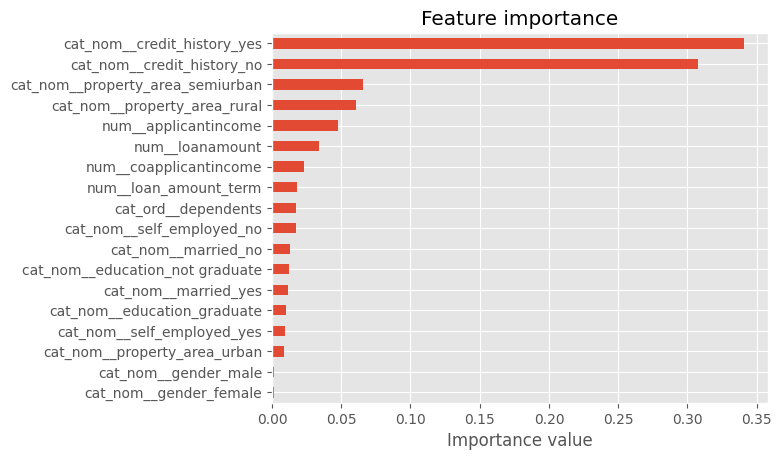

In [19]:
feature_names = rf_best.named_steps['preprocessing'].get_feature_names_out()
importances = rf_best.named_steps.model.feature_importances_

importances_series = pd.Series(importances, index=feature_names)
importances_series.sort_values(inplace=True, ascending=True)

with plt.style.context('ggplot'):
    importances_series.plot.barh(xlabel='Importance value', title='Feature importance')
    plt.show()

We can see that credit history has the most important effect on the model’s decisions. Some influence also comes from the features property_area, applicant_income, and loan_amount. The feature gender has almost no impact on the decision. Other features have relatively small influence on the decisions. We can say that most predictions about feature importance from the EDA were correct.

# Save models

In [64]:
joblib.dump(lr_best, '../models/logistic_regression.joblib')
joblib.dump(svm_best, '../models/svm.joblib')
joblib.dump(rf_best, '../models/random_forest.joblib')
joblib.dump(xgboost_best, '../models/xgboost.joblib')

['../models/xgboost.joblib']